In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [5]:
path = "/Users/melo/Library/CloudStorage/OneDrive-epfl.ch/Data/Commodities/commodities quantity/beef-and-buffalo-meat-production-tonnes/beef-and-buffalo-meat-production-tonnes.csv"
cattle= pd.read_csv(path)
cattle.head() 

,Entity,Code,Year,Beef and buffalo meat - Production (tonnes)
0,Afghanistan,AFG,1961,43000.0
1,Afghanistan,AFG,1962,45800.0
2,Afghanistan,AFG,1963,47250.0
3,Afghanistan,AFG,1964,48000.0
4,Afghanistan,AFG,1965,48700.0


In [6]:
cattle_world = cattle[cattle["Entity"] == "World"].reset_index(drop=True)
cattle_world.head()


,Entity,Code,Year,Beef and buffalo meat - Production (tonnes)
0,World,OWID_WRL,1961,28753174.0
1,World,OWID_WRL,1962,30305242.0
2,World,OWID_WRL,1963,31973646.0
3,World,OWID_WRL,1964,32434628.0
4,World,OWID_WRL,1965,33038106.0


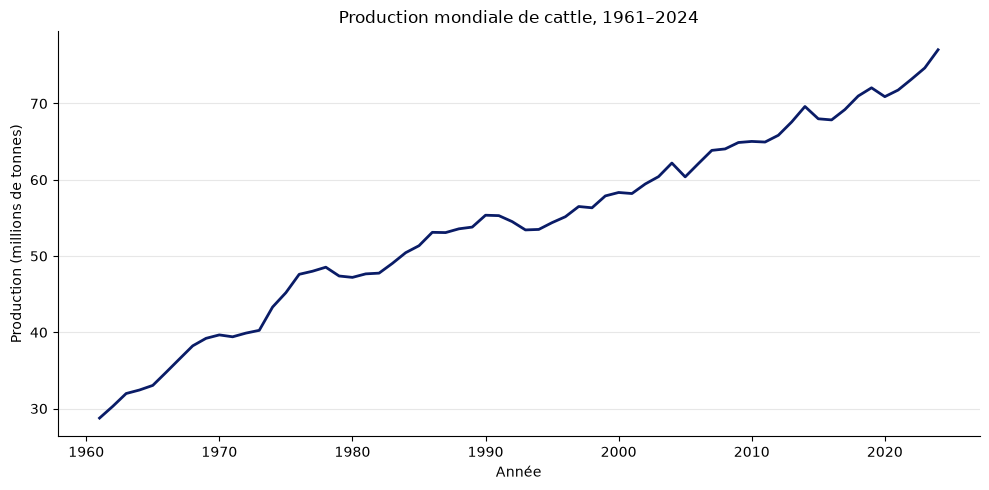

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(cattle_world["Year"], cattle_world["Beef and buffalo meat - Production (tonnes)"] / 1e6, color="#0a1c67", linewidth=2)
ax.set_title("Production mondiale de cattle, 1961–2024")
ax.set_xlabel("Année")
ax.set_ylabel("Production (millions de tonnes)")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [9]:
cattle_pays = cattle[cattle["Code"].notna() & ~cattle["Code"].str.startswith("OWID_")]

prod_par_pays = (
    cattle_pays.groupby("Entity")["Beef and buffalo meat - Production (tonnes)"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"Entity": "pays", "Beef and buffalo meat - Production (tonnes)": "production_totale_t"})
)
prod_par_pays.head(20)

,pays,production_totale_t
0,United States,7.028479e+08
1,Brazil,3.135003e+08
2,China,1.929304e+08
3,Argentina,1.740239e+08
4,India,1.387956e+08
5,Australia,1.114606e+08
6,France,1.029362e+08
7,Germany,9.451882e+07
8,Mexico,7.843580e+07
9,Canada,6.817930e+07


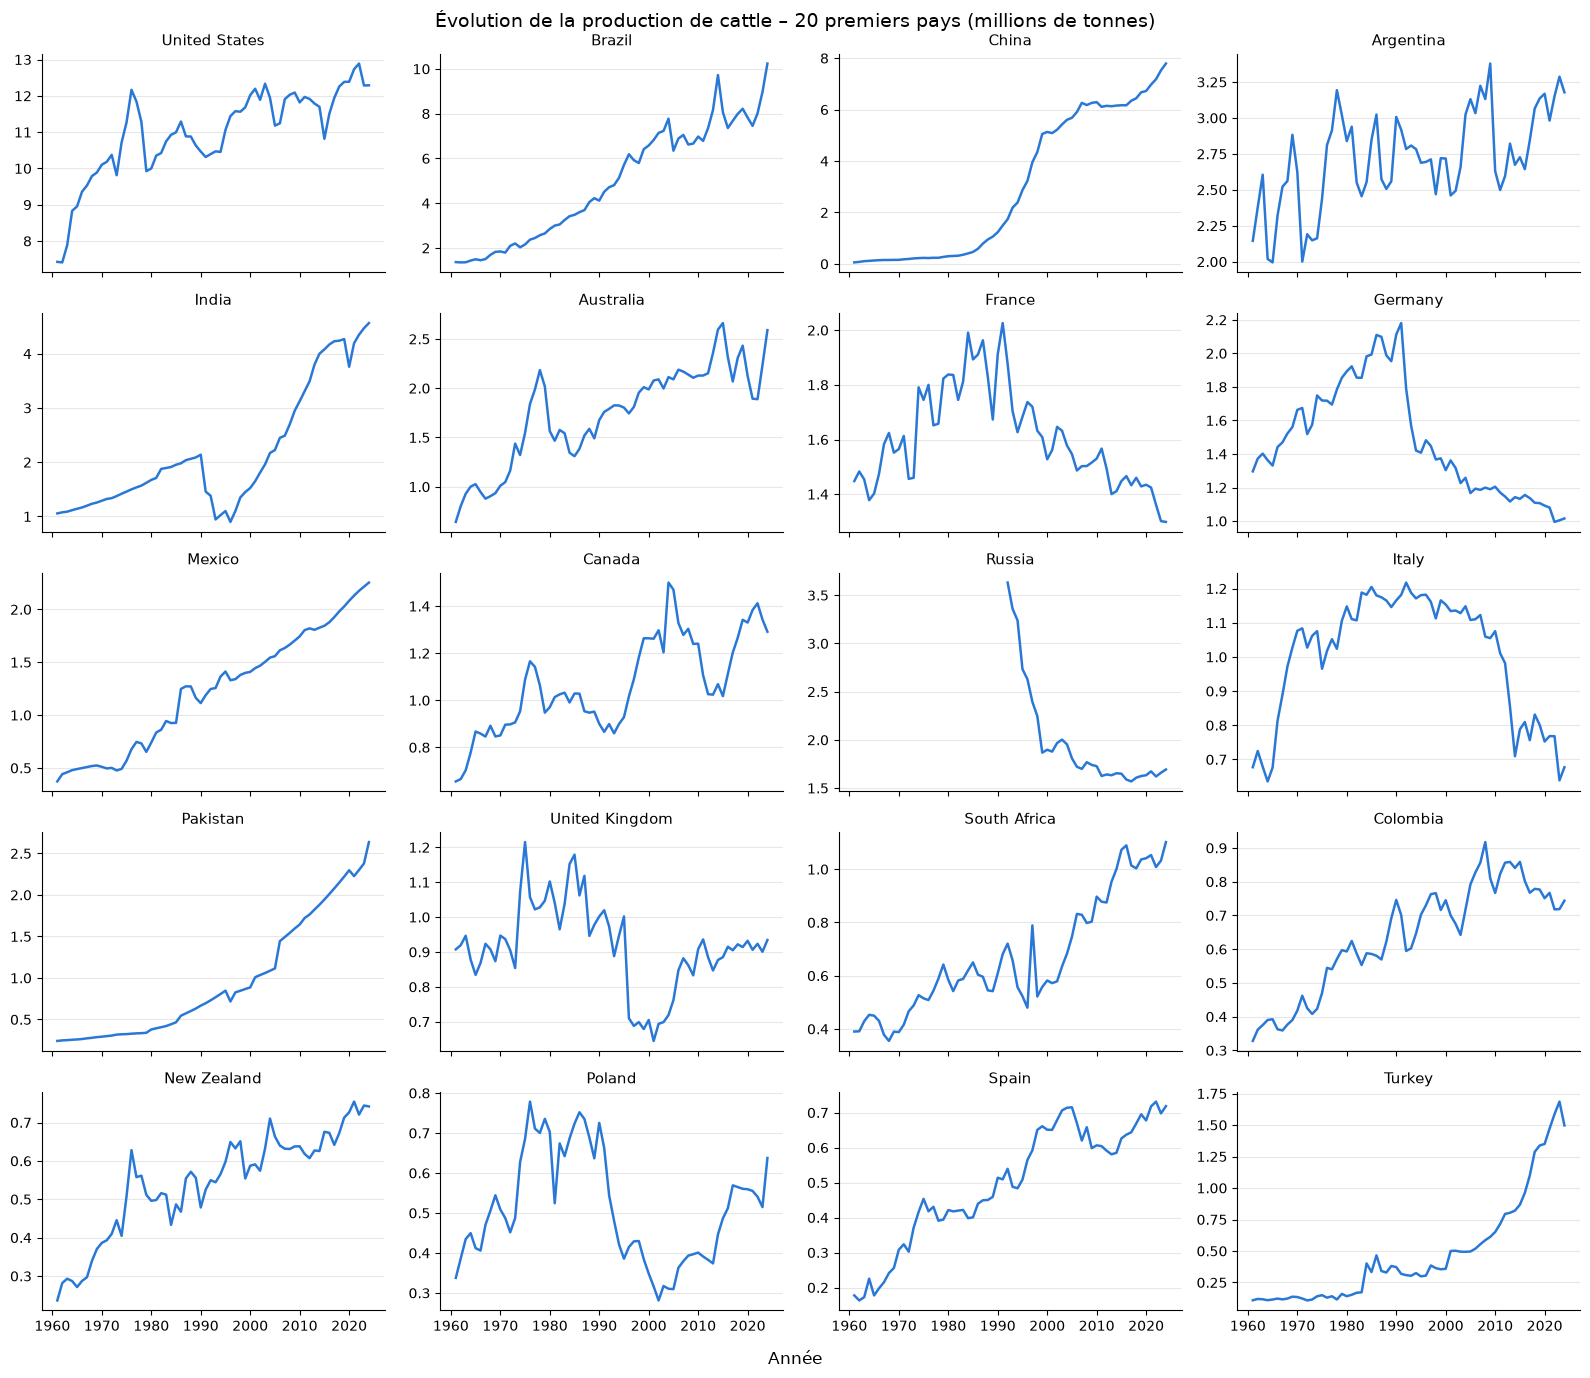

In [10]:
top20 = prod_par_pays.head(20)["pays"].tolist()
data = cattle_pays[cattle_pays["Entity"].isin(top20)]

fig, axes = plt.subplots(5, 4, figsize=(16, 14), sharex=True)
for ax, pays in zip(axes.flat, top20):
    d = data[data["Entity"] == pays]
    ax.plot(d["Year"], d["Beef and buffalo meat - Production (tonnes)"] / 1e6, color="#2a78d6", linewidth=1.8)
    ax.set_title(pays, fontsize=11)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Évolution de la production de cattle – 20 premiers pays (millions de tonnes)", fontsize=14)
fig.supxlabel("Année")
plt.tight_layout()
plt.show()